_Neural Data Science_

Lecturer: Dr. Jan Lause, Prof. Dr. Philipp Berens

Tutors: Jonas Beck, Fabio Seel, Julius Würzler

Summer term 2025

Student names: <span style='background: yellow'>*FILL IN YOUR NAMES HERE* </span>

LLM Disclaimer: <span style='background: yellow'>*Did you use an LLM to solve this exercise? If yes, which one and where did you use it? [Copilot, Claude, ChatGPT, etc.]* </span>

# Coding Lab 3

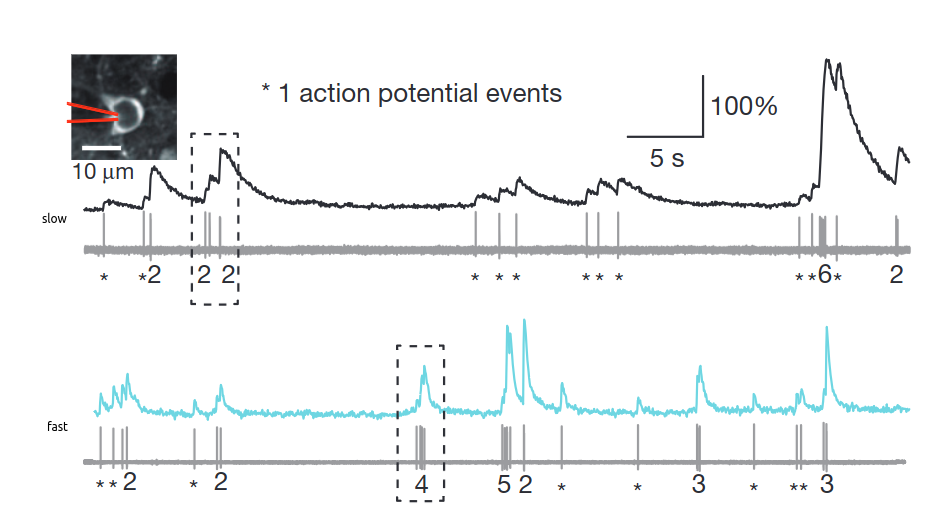

In this notebook you will work with 2 photon calcium recordings from mouse V1 and retina. For details see [Chen et al. 2013](https://www.nature.com/articles/nature12354) and [Theis et al. 2016](https://www.cell.com/neuron/pdf/S0896-6273(16)30073-3.pdf). Two-photon imaging is widely used to study computations in populations of neurons. 

In this exercise sheet we will study properties of different indicators and work on methods to infer spikes from calcium traces. All data is provided at a sampling rate of 100 Hz. For easier analysis, please resample it to 25 Hz. `scipy.signal.decimate` can help here, but note that it is only meant for continous signals. 

__Data__: Download the data file ```nds_cl_3_*.csv``` from ILIAS and save it in a subfolder ```../data/```. Note, some recordings were of shorter duration, hence their columns are padded. 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from __future__ import annotations

%matplotlib inline

%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearn

Last updated: 2025-05-10 16:14:17CEST

Python implementation: CPython
Python version       : 3.9.6
IPython version      : 8.18.1

sklearn: 1.5.2

pandas    : 2.2.3
scipy     : 1.13.1
matplotlib: 3.9.2
numpy     : 2.0.2
seaborn   : 0.13.2

Watermark: 2.5.0



In [2]:
plt.style.use("../matplotlib_style.txt")

## Load data

In [3]:
# ogb dataset from Theis et al. 2016 Neuron
ogb_calcium = pd.read_csv("../data/nds_cl_3_ogb_calcium.csv", header=0)
ogb_spikes = pd.read_csv("../data/nds_cl_3_ogb_spikes.csv", header=0)
print(f"[OGB] calcium: {ogb_calcium.shape}, spikes: {ogb_spikes.shape}")

# gcamp dataset from Chen et al. 2013 Nature
gcamp_calcium = pd.read_csv("../data/nds_cl_3_gcamp2_calcium.csv", header=0)
gcamp_spikes = pd.read_csv("../data/nds_cl_3_gcamp2_spikes.csv", header=0)
print(f"[GCaMP] calcium: {gcamp_calcium.shape}, spikes: {gcamp_spikes.shape}")

# spike dataframe
ogb_spikes.head()

[OGB] calcium: (71986, 11), spikes: (71986, 11)
[GCaMP] calcium: (23973, 37), spikes: (23973, 37)


,0,1,2,3,4,5,6,7,8,9,10
0,0,0,0.0,0.0,0,0,0,0.0,0,0.0,0
1,0,0,0.0,0.0,0,1,0,0.0,0,0.0,0
2,0,0,0.0,0.0,0,0,0,0.0,0,0.0,0
3,0,0,0.0,0.0,0,1,0,0.0,0,0.0,0
4,0,0,0.0,0.0,0,0,0,0.0,0,0.0,0


## Task 1: Visualization of calcium and spike recordings

We start again by plotting the raw data - calcium and spike traces in this case. One dataset has been recorded using the synthetic calcium indicator OGB-1 at population imaging zoom (~100 cells in a field of view) and the other one using the genetically encoded indicator GCamp6f zooming in on individual cells. Plot the traces of an example cell from each dataset to show how spikes and calcium signals are related. A good example cell for the OGB-dataset is cell 5. For the CGamp-dataset a good example is cell 6. Align the traces by eye (add a small offset to the plot) such that a valid comparison is possible and zoom in on a small segment of tens of seconds.

*Grading: 3 pts*

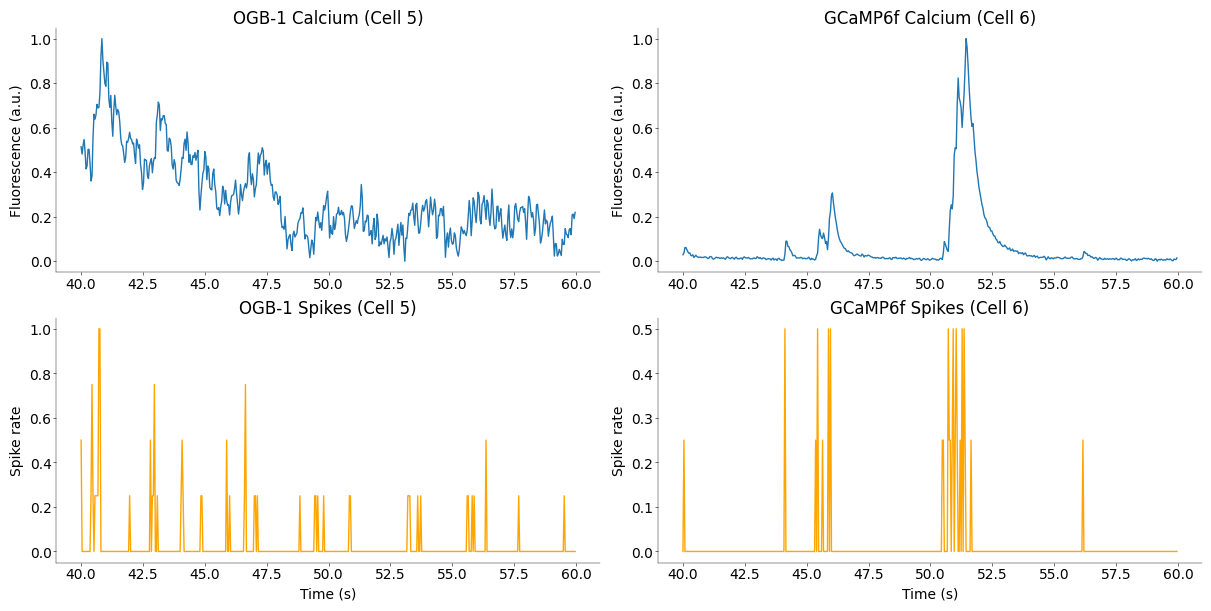

In [4]:
# --------------------------------
# Resample and prepare data (1 pt)
# --------------------------------


# Normalize signals for comparison
def min_max_scale(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x) + 1e-10)


def resample_spikes(spikes: np.ndarray, factor: int) -> np.ndarray:
    """
    Resample spike data by averaging over windows of size `factor`.

    Args:
        spikes (np.ndarray): Spike data (time points x neurons).
        factor (int): Downsampling factor (e.g., 4 for 100 Hz to 25 Hz).

    Returns:
        np.ndarray: Resampled spike data.
    """
    n_samples = spikes.shape[0]
    n_resampled = n_samples // factor
    reshaped = spikes[: n_resampled * factor].reshape(n_resampled, factor, -1)
    return reshaped.mean(axis=1)


# Check and handle NaNs in raw data
if ogb_calcium.isna().any().any():
    ogb_calcium = ogb_calcium.fillna(0)
if ogb_spikes.isna().any().any():
    ogb_spikes = ogb_spikes.fillna(0)
if gcamp_calcium.isna().any().any():
    gcamp_calcium = gcamp_calcium.fillna(0)
if gcamp_spikes.isna().any().any():
    gcamp_spikes = gcamp_spikes.fillna(0)

# Resample to 25 Hz (from 100 Hz, factor = 4)
factor = 4
ogb_calcium_resampled = signal.decimate(ogb_calcium.values, factor, axis=0)
ogb_spikes_resampled = resample_spikes(ogb_spikes.values, factor)

gcamp_calcium_resampled = signal.decimate(gcamp_calcium.values, factor, axis=0)
gcamp_spikes_resampled = resample_spikes(gcamp_spikes.values, factor)

# --- Plotting parameters ---
ogb_cell_idx = 5
gcamp_cell_idx = 6

# Zoom into a 20 second segment: 20 s × 25 Hz = 500 samples
start = 1000
end = start + 500
time_ogb = np.arange(start, end) / 25  # seconds
time_gcamp = np.arange(start, end) / 25

fig, axs = plt.subplots(2, 2, figsize=(12, 6))
# --------------------
# Plot OGB data (1 pt)
# --------------------

axs[0, 0].plot(
    time_ogb,
    min_max_scale(ogb_calcium_resampled[start:end, ogb_cell_idx]),
    label="OGB calcium",
)
axs[0, 0].set_title("OGB-1 Calcium (Cell 5)")
axs[0, 0].set_ylabel("Fluorescence (a.u.)")

ogb_spike_offset = 0
axs[1, 0].plot(
    time_ogb,
    ogb_spikes_resampled[
        start + ogb_spike_offset : end + ogb_spike_offset, ogb_cell_idx
    ],
    label="OGB spikes",
    color="orange",
)

axs[1, 0].set_title("OGB-1 Spikes (Cell 5)")
axs[1, 0].set_xlabel("Time (s)")
axs[1, 0].set_ylabel("Spike rate")

# ----------------------
# Plot GCamp data (1 pt)
# ----------------------

axs[0, 1].plot(
    time_gcamp,
    min_max_scale(gcamp_calcium_resampled[start:end, gcamp_cell_idx]),
    label="GCaMP calcium",
)
axs[0, 1].set_title("GCaMP6f Calcium (Cell 6)")
axs[0, 1].set_ylabel("Fluorescence (a.u.)")

axs[1, 1].plot(
    time_gcamp,
    gcamp_spikes_resampled[start:end, gcamp_cell_idx],
    label="GCaMP spikes",
    color="orange",
)
axs[1, 1].set_title("GCaMP6f Spikes (Cell 6)")
axs[1, 1].set_xlabel("Time (s)")
axs[1, 1].set_ylabel("Spike rate")

# plt.suptitle("Example Calcium and Spike Traces (Resampled to 25Hz)", fontsize=14)
plt.show()

## Bonus Task (Optional): Calcium preprocessing

To improve the quality of the inferred spike trains, further preprocessing steps can undertaken. This includes filtering and smoothing of the calcium trace.

Implement a suitable filter and local averaging procedure as discussed in the lecture. Explain your choices and discuss how it helps!

_Grading: 1 BONUS point_

_BONUS Points do not count for this individual coding lab, but sum up to 5% of your **overall coding lab grade**. There are 4 BONUS points across all coding labs._

In [60]:
def iterative_smoothing(trace, thr_noise=1.0, max_iter=5000):
    """Iterative smoothing procedure as described in Yaksi & Friedrich (2006).

    Parameters
    ----------
    trace : np.ndarray
        Input calcium trace (filtered).
    thr_noise : float
        Noise threshold for determining small peaks.
    max_iter : int
        Maximum number of iterations.

    Returns
    -------
    smoothed : np.ndarray
        Smoothed trace.
    """
    smoothed = trace.copy()
    for _ in range(max_iter):
        # Find all peaks
        peaks, _ = signal.find_peaks(smoothed)
        if len(peaks) < 3:
            break

        # Compute amplitudes relative to previous peak
        peak_amplitudes = smoothed[peaks]
        diffs = np.abs(np.diff(peak_amplitudes, prepend=peak_amplitudes[0]))

        # Find smallest peak (in terms of amplitude difference to previous)
        min_idx = np.argmin(diffs)
        if diffs[min_idx] >= thr_noise:
            break  # stop if all peaks are above noise threshold

        # Define bounds of smoothing region
        if min_idx == 0 or min_idx == len(peaks) - 1:
            continue  # skip if at boundary
        left = peaks[min_idx - 1]
        right = peaks[min_idx + 1]

        # Smooth segment between peaks
        segment = smoothed[left : right + 1]
        smoothed_segment = segment.copy()
        smoothed_segment[1:-1] = (segment[:-2] + segment[1:-1] + segment[2:]) / 3
        smoothed[left : right + 1] = smoothed_segment

    return smoothed


def preprocess_ca(ca: np.ndarray, fs: float, thr_noise=1.0) -> np.ndarray:
    """Preprocess calcium trace using Butterworth filter and iterative smoothing.

    Parameters
    ----------
    ca : np.ndarray
        Raw calcium trace.
    fs : float
        Sampling frequency (Hz).
    thr_noise : float
        Noise threshold for peak smoothing.

    Returns
    -------
    np.ndarray
        Preprocessed calcium trace.
    """
    # Low-pass Butterworth filter
    cutoff = 0.2 * fs
    b, a = signal.butter(N=4, Wn=cutoff, fs=fs, btype="low")
    ca_filtered = signal.filtfilt(b, a, ca)

    # Iterative local averaging from Yaksi & Friedrich (2006)
    ca_smoothed = iterative_smoothing(ca_filtered, thr_noise=thr_noise)
    return ca_smoothed


# Preprocess calcium traces
ogb_calcium_preprocessed = np.zeros_like(ogb_calcium_resampled)
gcamp_calcium_preprocessed = np.zeros_like(gcamp_calcium_resampled)
for i in range(ogb_calcium_resampled.shape[1]):
    ogb_calcium_preprocessed[:, i] = preprocess_ca(
        ogb_calcium_resampled[:, i], fs=25, thr_noise=20.0
    )
for i in range(gcamp_calcium_resampled.shape[1]):
    gcamp_calcium_preprocessed[:, i] = preprocess_ca(
        gcamp_calcium_resampled[:, i], fs=25, thr_noise=20.0
    )

To improve the quality of deconvolved spike trains, we implemented the two-step preprocessing method as described in **Yaksi & Friedrich (2006)**:

**1. Butterworth Filtering**

We used a 4th-order low-pass Butterworth filter with a cutoff frequency of 0.2×sampling rate. This step reduces high-frequency noise while preserving the sharp onset of calcium transients caused by action potentials.

**2. Iterative Local Averaging**

Inspired by Supplementary Figure 3 of the paper, we implemented an **iterative smoothing procedure** that identifies small peaks (amplitudes below a threshold, `thr_noise = 1.0`) and locally averages the trace between neighboring peaks. This step preserves high-amplitude spike-related signals while selectively smoothing out low-amplitude noise.

At each iteration:
- Peaks are detected.
- The peak with the smallest amplitude difference to the previous peak is identified.
- If this difference is less than `thr_noise`, the segment between its adjacent peaks is smoothed via local averaging.
- This process continues until either all such small peaks are smoothed or a maximum number of iterations (default 5000) is reached.

**Why this helps**

This method suppresses noise that might otherwise lead to spurious spikes during deconvolution. Unlike global smoothing (e.g., moving average), this approach **preserves temporal resolution** and **sharp transients**, improving the precision of spike inference.



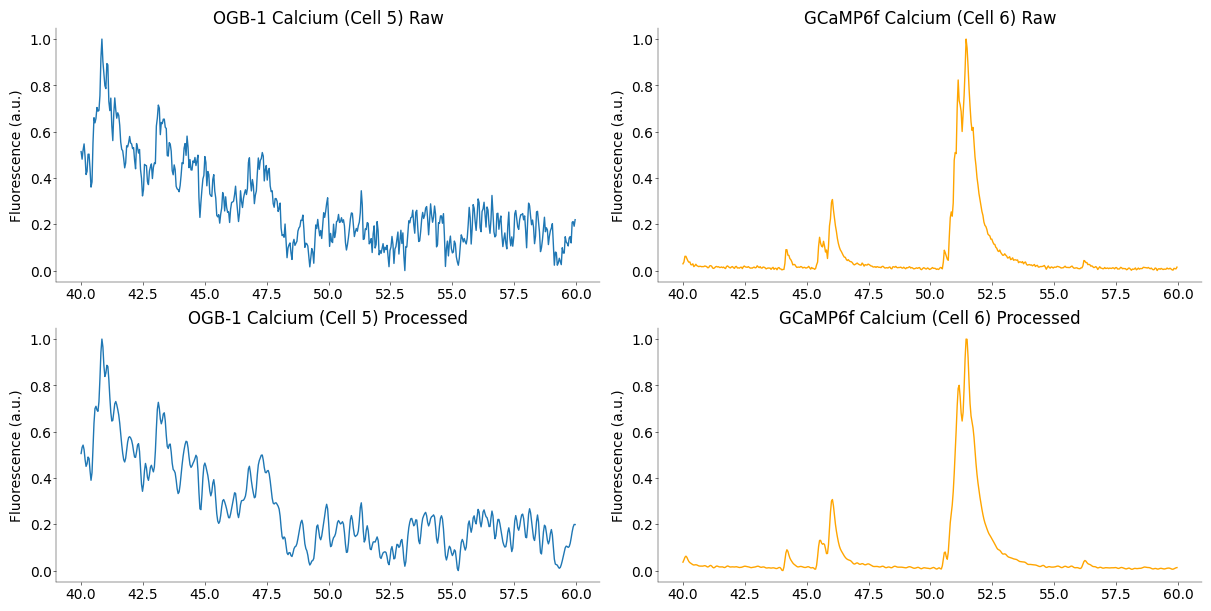

In [61]:
# Plot preprocessed calcium traces
fig, axs = plt.subplots(2, 2, figsize=(12, 6))

axs[0, 0].plot(
    time_ogb,
    min_max_scale(ogb_calcium_resampled[start:end, ogb_cell_idx]),
    label="OGB calcium",
)
axs[0, 0].set_title("OGB-1 Calcium (Cell 5) Raw")
axs[0, 0].set_ylabel("Fluorescence (a.u.)")

axs[1, 0].plot(
    time_ogb,
    min_max_scale(ogb_calcium_preprocessed[start:end, ogb_cell_idx]),
    label="OGB calcium",
)
axs[1, 0].set_title("OGB-1 Calcium (Cell 5) Processed")
axs[1, 0].set_ylabel("Fluorescence (a.u.)")

axs[0, 1].plot(
    time_gcamp,
    min_max_scale(gcamp_calcium_resampled[start:end, gcamp_cell_idx]),
    label="GCaMP calcium",
    color="orange",
)
axs[0, 1].set_title("GCaMP6f Calcium (Cell 6) Raw")
axs[0, 1].set_ylabel("Fluorescence (a.u.)")

axs[1, 1].plot(
    time_gcamp,
    min_max_scale(gcamp_calcium_preprocessed[start:end, gcamp_cell_idx]),
    label="GCaMP calcium",
    color="orange",
)
axs[1, 1].set_title("GCaMP6f Calcium (Cell 6) Processed")
axs[1, 1].set_ylabel("Fluorescence (a.u.)")

plt.show()

## Task 2: Simple deconvolution

It is clear from the above plots that the calcium events happen in relationship to the spikes. As a first simple algorithm implement a deconvolution approach like presented in the lecture in the function `deconv_ca`. Assume an exponential kernel where the decay constant depends on the indicator ($\tau_{OGB}= 0.5 s$, $\tau_{GCaMP}= 0.1 s$). Note there can be no negative rates! Plot the kernel as well as an example cell with true and deconvolved spike rates. Scale the signals such as to facilitate comparisons. You can use functions from `scipy` for this. Explain your results and your choice of kernel.

*Grading: 6 pts*


In [65]:
def deconv_ca(ca: np.ndarray, tau: float, dt: float) -> np.ndarray:
    """Compute the deconvolution of the calcium signal.

    Parameters
    ----------

    ca: np.array, (n_points,)
        Calcium trace

    tau: float
        decay constant of conv kernel

    dt: float
        sampling interval.

    Return
    ------

    sp_hat: np.array
    """

    # --------------------------------------------
    # apply devonvolution to calcium signal (1 pt)
    # --------------------------------------------

    # Create truncated exponential decay kernel: exp(-t / tau) truncated at t = 2*tau (per Yaksi & Friedrich)
    t_max = 2 * tau  # truncate kernel at 2 × tau
    # kernel_len = int(t_max / dt)
    t = np.arange(0, t_max, dt)
    kernel = np.exp(-t / tau)
    kernel /= kernel.sum()  # normalize kernel so it integrates to 1

    # Deconvolve:

    n = ca.shape[0]
    sp_hat, _ = signal.deconvolve(ca, kernel)

    # Enforce non-negative spike estimates (biological constraint)
    sp_hat = np.clip(sp_hat, 0, None)

    return sp_hat

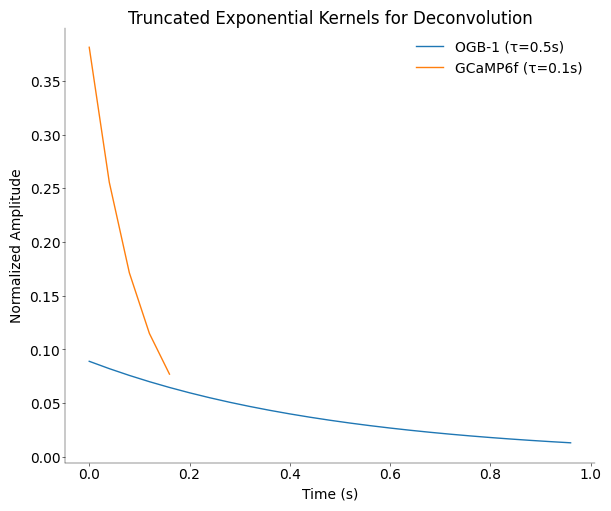

In [66]:
# -------------------------
# Plot the 2 kernels (1 pt)
# -------------------------
fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")

# Parameters
dt = 1 / 25  # sampling interval at 25 Hz
tau_ogb = 0.5  # in seconds
tau_gcamp = 0.1  # in seconds

# Create time axes for truncated kernels (up to 2 * tau)
t_ogb = np.arange(0, 2 * tau_ogb, dt)
t_gcamp = np.arange(0, 2 * tau_gcamp, dt)

# Compute and normalize kernels
kernel_ogb = np.exp(-t_ogb / tau_ogb)
kernel_ogb /= kernel_ogb.sum()

kernel_gcamp = np.exp(-t_gcamp / tau_gcamp)
kernel_gcamp /= kernel_gcamp.sum()

# Plot the kernels
ax.plot(t_ogb, kernel_ogb, label="OGB-1 (τ=0.5s)")
ax.plot(t_gcamp, kernel_gcamp, label="GCaMP6f (τ=0.1s)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Normalized Amplitude")
ax.set_title("Truncated Exponential Kernels for Deconvolution")
ax.legend()
plt.show()

### Questions (1 pt)
1) Explain how you constructed the kernels

We modeled the calcium transient response as a truncated exponential decay function of the form `exp(-t / τ)`, where `τ` is the decay constant specific to the calcium indicator (0.5 s for OGB-1 and 0.1 s for GCaMP6f). Following the method described in Yaksi & Friedrich (2006), we truncated the kernel at `t = 2τ` to retain the meaningful portion of the transient while reducing computational complexity. We then normalized each kernel to ensure that the total area under the curve is 1, making the convolution energy-preserving and suitable for deconvolution.

2) How do the indicators / kernels compare?

The main difference lies in the decay constants: GCaMP6f has a much faster decay (0.1 s) compared to OGB-1 (0.5 s). This results in a sharper, narrower kernel for GCaMP6f, making it more sensitive to closely spaced spikes. In contrast, the OGB-1 kernel is broader and integrates the calcium signal over a longer time window. This means it smooths over multiple spikes but also blurs temporal precision. The choice of kernel directly affects how well we can resolve individual spikes after deconvolution.

3) What are pros and cons of each indicator?

TO DO

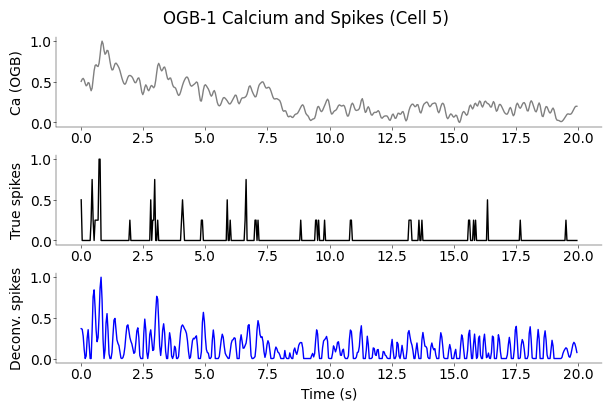

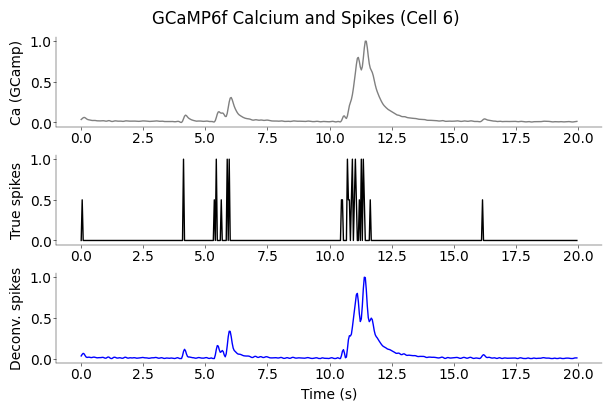

In [64]:
# ----------------------------------------------------------------------
# Compare true and deconvolved spikes rates for the OGB and GCamP cells.
# What do you notice? Why is that? (3 pts)
# ----------------------------------------------------------------------

# Apply deconvolution to selected cells
ogb_cell = ogb_calcium_preprocessed[:, ogb_cell_idx]
gcamp_cell = gcamp_calcium_preprocessed[:, gcamp_cell_idx]

# Perform deconvolution
ogb_deconv = deconv_ca(ogb_cell, tau=tau_ogb, dt=dt)
gcamp_deconv = deconv_ca(gcamp_cell, tau=tau_gcamp, dt=dt)


# Scale signals for comparison
ogb_calcium_scaled = min_max_scale(ogb_cell[start:end])
ogb_spikes_scaled = min_max_scale(ogb_spikes_resampled[start:end, ogb_cell_idx])
ogb_deconv_scaled = min_max_scale(ogb_deconv[start:end])

gcamp_calcium_scaled = min_max_scale(gcamp_cell[start:end])
gcamp_spikes_scaled = min_max_scale(gcamp_spikes_resampled[start:end, gcamp_cell_idx])
gcamp_deconv_scaled = min_max_scale(gcamp_deconv[start:end])

fig, axs = plt.subplots(
    3, 1, figsize=(6, 4), height_ratios=[1, 1, 1], gridspec_kw=dict(hspace=0)
)

# OGB Cell


t_ogb = np.arange(len(ogb_deconv_scaled)) * dt
axs[0].plot(t_ogb, ogb_calcium_scaled, color="gray")
axs[0].set_ylabel("Ca (OGB)")

axs[1].plot(t_ogb, ogb_spikes_scaled, color="black")
axs[1].set_ylabel("True spikes")

axs[2].plot(t_ogb, ogb_deconv_scaled, color="blue")
axs[2].set_ylabel("Deconv. spikes")
axs[2].set_xlabel("Time (s)")
fig.suptitle("OGB-1 Calcium and Spikes (Cell 5)")

fig, axs = plt.subplots(
    3, 1, figsize=(6, 4), height_ratios=[1, 1, 1], gridspec_kw=dict(hspace=0)
)

# GCamp Cell

t_gcamp = np.arange(len(gcamp_deconv_scaled)) * dt
axs[0].plot(t_gcamp, gcamp_calcium_scaled, color="gray")
axs[0].set_ylabel("Ca (GCamp)")

axs[1].plot(t_gcamp, gcamp_spikes_scaled, color="black")
axs[1].set_ylabel("True spikes")

axs[2].plot(t_gcamp, gcamp_deconv_scaled, color="blue")
axs[2].set_ylabel("Deconv. spikes")
axs[2].set_xlabel("Time (s)")
fig.suptitle("GCaMP6f Calcium and Spikes (Cell 6)")
plt.show()

## Task 3: Run more complex algorithm

As reviewed in the lecture, a number of more complex algorithms for inferring spikes from calcium traces have been developed. Run an implemented algorithm on the data and plot the result. There is a choice of algorithms available, for example:

* Vogelstein: [oopsi](https://github.com/liubenyuan/py-oopsi)
* Theis: [c2s](https://github.com/lucastheis/c2s)
* Friedrich: [OASIS](https://github.com/j-friedrich/OASIS)

*Grading: 3 pts*


In [37]:
# run this cell to download the oopsi.py file and put it in the same folder as this notebook
!wget https://raw.githubusercontent.com/liubenyuan/py-oopsi/master/oopsi.py
import oopsi

--2025-05-10 16:28:54--  https://raw.githubusercontent.com/liubenyuan/py-oopsi/master/oopsi.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7973 (7,8K) [text/plain]
Saving to: ‘oopsi.py.3’

oopsi.py.3          100%[===================>]   7,79K  --.-KB/s    in 0,001s  

2025-05-10 16:28:54 (14,9 MB/s) - ‘oopsi.py.3’ saved [7973/7973]



In [51]:
# ----------------------------------------------------------------------
# Apply one of the advanced algorithms to the OGB and GCamp Cells (1 pt)
# ----------------------------------------------------------------------

# Apply OOPSI algorithm to both example cells
ogb_cell_ts = ogb_calcium_preprocessed[:, ogb_cell_idx]
gcamp_cell_ts = gcamp_calcium_preprocessed[:, gcamp_cell_idx]

# Min-max normalize for OOPSI
ogb_cell_norm = min_max_scale(ogb_cell_ts)
gcamp_cell_norm = min_max_scale(gcamp_cell_ts)

# Run OOPSI algorithm
V_ogb, P_ogb = oopsi.fast(ogb_cell_norm, dt=dt)
V_gcamp, P_gcamp = oopsi.fast(gcamp_cell_norm, dt=dt)

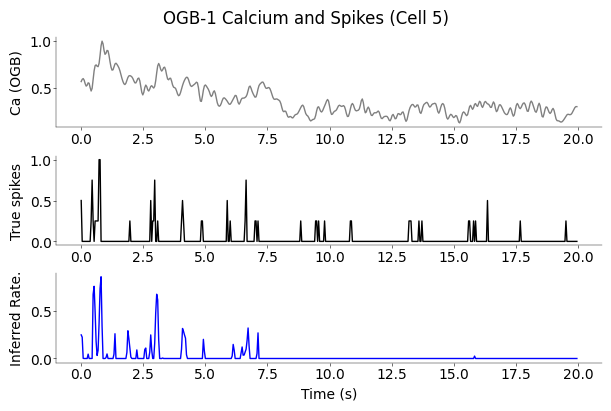

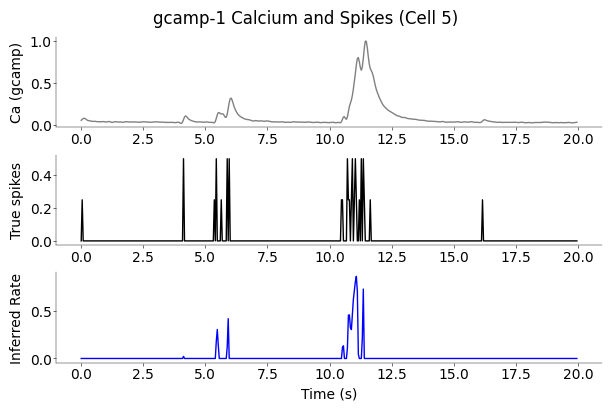

In [52]:
# -------------------------------------------------------------------------------
# Plot the results for the gcamp and GCamp Cells and describe the results (1+1 pts)
# -------------------------------------------------------------------------------

fig, axs = plt.subplots(
    3, 1, figsize=(6, 4), height_ratios=[1, 1, 1], gridspec_kw=dict(hspace=0)
)

# OGB Cell
ogb_calcium_segment = ogb_cell_norm[start:end]
ogb_spikes_segment = ogb_spikes_resampled[start:end, ogb_cell_idx]
ogb_oopsi_segment = V_ogb[start:end]

t_ogb = np.arange(len(ogb_oopsi_segment)) * dt
axs[0].plot(t_ogb, ogb_calcium_segment, color="gray")
axs[0].set_ylabel("Ca (OGB)")

axs[1].plot(t_ogb, ogb_spikes_segment, color="black")
axs[1].set_ylabel("True spikes")

axs[2].plot(t_ogb, ogb_oopsi_segment, color="blue")
axs[2].set_ylabel("Inferred Rate.")
axs[2].set_xlabel("Time (s)")
fig.suptitle("OGB-1 Calcium and Spikes (Cell 5)")

fig, axs = plt.subplots(
    3, 1, figsize=(6, 4), height_ratios=[1, 1, 1], gridspec_kw=dict(hspace=0)
)

# GCamP Cell

gcamp_calcium_segment = gcamp_cell_norm[start:end]
gcamp_spikes_segment = gcamp_spikes_resampled[start:end, gcamp_cell_idx]
gcamp_oopsi_segment = V_gcamp[start:end]

t_gcamp = np.arange(len(gcamp_oopsi_segment)) * dt
axs[0].plot(t_gcamp, gcamp_calcium_segment, color="gray")
axs[0].set_ylabel("Ca (gcamp)")

axs[1].plot(t_gcamp, gcamp_spikes_segment, color="black")
axs[1].set_ylabel("True spikes")

axs[2].plot(t_gcamp, gcamp_oopsi_segment, color="blue")
axs[2].set_ylabel("Inferred Rate")
axs[2].set_xlabel("Time (s)")
fig.suptitle("gcamp-1 Calcium and Spikes (Cell 5)")

plt.show()

## Task 4: Evaluation of algorithms

To formally evaluate the algorithms on the two datasets run the deconvolution algorithm and the more complex one on all cells and compute the correlation between true and inferred spike trains. `DataFrames` from the `pandas` package are a useful tool for aggregating data and later plotting it. Create a dataframe with columns

* algorithm
* correlation
* indicator

and enter each cell. Plot the results using `stripplot` and/or `boxplot` in the `seaborn` package. Note these functions provide useful options for formatting the
plots. See their documentation, i.e. `sns.boxplot?`.

*Grading: 5 pts*


First, evaluate on OGB data and create OGB dataframe. Then repeat for GCamp and combine the two dataframes.

In [53]:
# ----------------------------------------------------------
# Evaluate the algorithms on the OGB and GCamp cells (2 pts)
# ----------------------------------------------------------


def match_length(spike_result: np.ndarray, target_len: int) -> np.ndarray:
    """
    Pad spike output to match the length of the ground truth spike trace.

    Args:
        spike_result (np.ndarray): Estimated signal.
        target_len (int): Desired output length (original signal length).

    Returns:
        np.ndarray: Padded signal.
    """
    pad_len = target_len - len(spike_result)
    if pad_len > 0:
        return np.concatenate([spike_result, np.zeros(pad_len)])
    else:
        return spike_result[:target_len]


def evaluate_algorithm(calcium, spikes, algorithm_fn, **kwargs):
    """Evaluate algorithm on all cells."""
    n_cells = calcium.shape[1]
    correlations = np.zeros(n_cells)

    for i in range(n_cells):
        # Get calcium and spike data for this cell
        ca = calcium[:, i]
        sp = spikes[:, i]

        # Min-max normalize calcium
        ca_norm = min_max_scale(ca)

        # Apply algorithm
        sp_hat = algorithm_fn(ca_norm, **kwargs)

        # Match length of estimated spikes to original spike trace
        sp_hat = match_length(sp_hat, len(sp))

        # Compute correlation
        correlations[i] = np.corrcoef(sp, sp_hat)[0, 1]

    return correlations


# Function to apply deconvolution
def apply_deconv(ca, tau=0.5, dt=1 / 25):
    return deconv_ca(ca, tau, dt)


# Function to apply OOPSI
def apply_oopsi(ca, dt=1 / 25):
    V, _ = oopsi.fast(ca, dt=dt)
    return V


# Evaluate algorithms on OGB data
ogb_deconv_corrs = evaluate_algorithm(
    ogb_calcium_preprocessed, ogb_spikes_resampled, apply_deconv, tau=tau_ogb, dt=dt
)

ogb_oopsi_corrs = evaluate_algorithm(
    ogb_calcium_preprocessed, ogb_spikes_resampled, apply_oopsi, dt=dt
)

# Evaluate algorithms on GCaMP data
gcamp_deconv_corrs = evaluate_algorithm(
    gcamp_calcium_preprocessed,
    gcamp_spikes_resampled,
    apply_deconv,
    tau=tau_gcamp,
    dt=dt,
)

gcamp_oopsi_corrs = evaluate_algorithm(
    gcamp_calcium_preprocessed, gcamp_spikes_resampled, apply_oopsi, dt=dt
)

In [54]:
# -------------------------------
# Construct the dataframe (1 pts)
# -------------------------------

df_ogb_deconv = pd.DataFrame(
    {
        "algorithm": "Deconvolution",
        "correlation": ogb_deconv_corrs,
        "indicator": "OGB-1",
    }
)

df_ogb_oopsi = pd.DataFrame(
    {"algorithm": "OOPSI", "correlation": ogb_oopsi_corrs, "indicator": "OGB-1"}
)

df_gcamp_deconv = pd.DataFrame(
    {
        "algorithm": "Deconvolution",
        "correlation": gcamp_deconv_corrs,
        "indicator": "GCaMP6f",
    }
)

df_gcamp_oopsi = pd.DataFrame(
    {"algorithm": "OOPSI", "correlation": gcamp_oopsi_corrs, "indicator": "GCaMP6f"}
)

df_all = pd.concat([df_ogb_deconv, df_ogb_oopsi, df_gcamp_deconv, df_gcamp_oopsi])

Combine both dataframes. Plot the performance of each indicator and algorithm. You should only need a single plot for this.

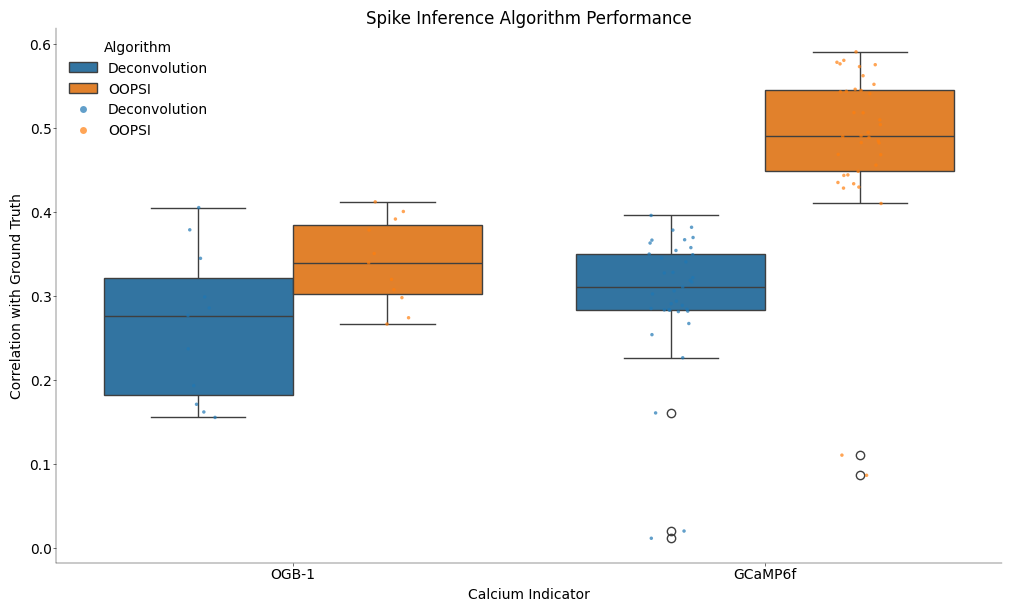

In [55]:
# ----------------------------------------------------------------------------
# Create Strip/Boxplot for both cells and algorithms Cell as described. (1 pt)
# Describe and explain the results briefly. (1 pt)
# ----------------------------------------------------------------------------

# Create strip/boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="indicator", y="correlation", hue="algorithm", data=df_all)
sns.stripplot(
    x="indicator",
    y="correlation",
    hue="algorithm",
    data=df_all,
    dodge=True,
    alpha=0.7,
    jitter=True,
)

plt.title("Spike Inference Algorithm Performance")
plt.xlabel("Calcium Indicator")
plt.ylabel("Correlation with Ground Truth")
plt.legend(title="Algorithm")
plt.show()

The results indicate:

- OOPSI generally outperforms simple deconvolution for both indicators
- GCaMP6f generally has better spike inference performance due to its faster dynamics
- There is considerable cell-to-cell variability in inference performance